# Heart Disease Prediction using Machine Learning

## Objective
Build a machine learning model to predict whether a patient has heart disease.

## Type
Binary Classification Problem

In [3]:
from google.colab import files
files.upload()

Saving heart.csv.csv to heart.csv.csv


{'heart.csv.csv': b'age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num\r\n63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,fixed defect,0\r\n67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,normal,2\r\n67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,reversable defect,1\r\n37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,normal,0\r\n41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,normal,0\r\n56,Male,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,normal,0\r\n62,Female,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,normal,3\r\n57,Female,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,normal,0\r\n63,Male,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,reversable defect,2\r\n53,Male,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,down

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("heart.csv.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,normal,0


## Data Understanding

The dataset contains medical features such as age, cholesterol, and heart rate.
The goal is to predict the presence of heart disease.

In [6]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   cp        920 non-null    object 
 3   trestbps  920 non-null    float64
 4   chol      920 non-null    float64
 5   fbs       920 non-null    bool   
 6   restecg   920 non-null    object 
 7   thalch    920 non-null    float64
 8   exang     920 non-null    bool   
 9   oldpeak   920 non-null    float64
 10  slope     920 non-null    object 
 11  thal      920 non-null    object 
 12  num       920 non-null    int64  
dtypes: bool(2), float64(4), int64(2), object(5)
memory usage: 81.0+ KB


,age,trestbps,chol,thalch,oldpeak,num
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,131.995652,199.908696,137.692391,0.853261,0.995652
std,9.424685,18.451300,109.040171,25.145235,1.058049,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,177.750000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,1.000000
75%,60.000000,140.000000,267.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [7]:
# Convert 'num' to binary target
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# Drop old column
df = df.drop('num', axis=1)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,target
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,normal,0


The original dataset contains a variable "num" with multiple levels of heart disease.
It was converted into a binary variable:
0 = no disease, 1 = presence of disease.

In [8]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


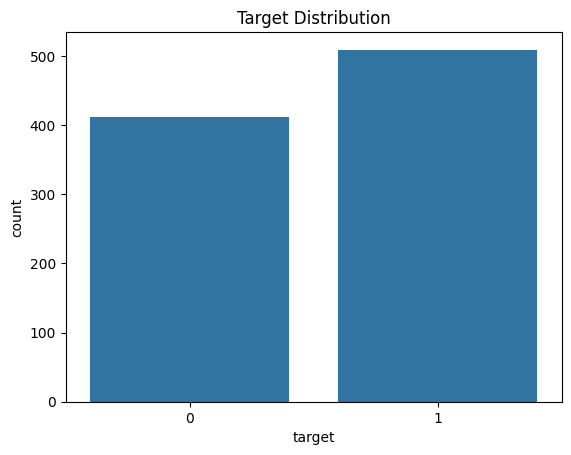

In [9]:
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

The dataset is relatively balanced between patients with and without heart disease.

In [10]:
# Convert categorical variables to numeric
df = pd.get_dummies(df, drop_first=True)

df.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,target,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,True,150.0,False,2.3,0,True,False,False,True,False,False,False,False,False,False
1,67,160.0,286.0,False,108.0,True,1.5,1,True,False,False,False,False,False,True,False,True,False
2,67,120.0,229.0,False,129.0,True,2.6,1,True,False,False,False,False,False,True,False,False,True
3,37,130.0,250.0,False,187.0,False,3.5,0,True,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,0,False,True,False,False,False,False,False,True,True,False


Categorical variables were converted into numerical format using one-hot encoding.

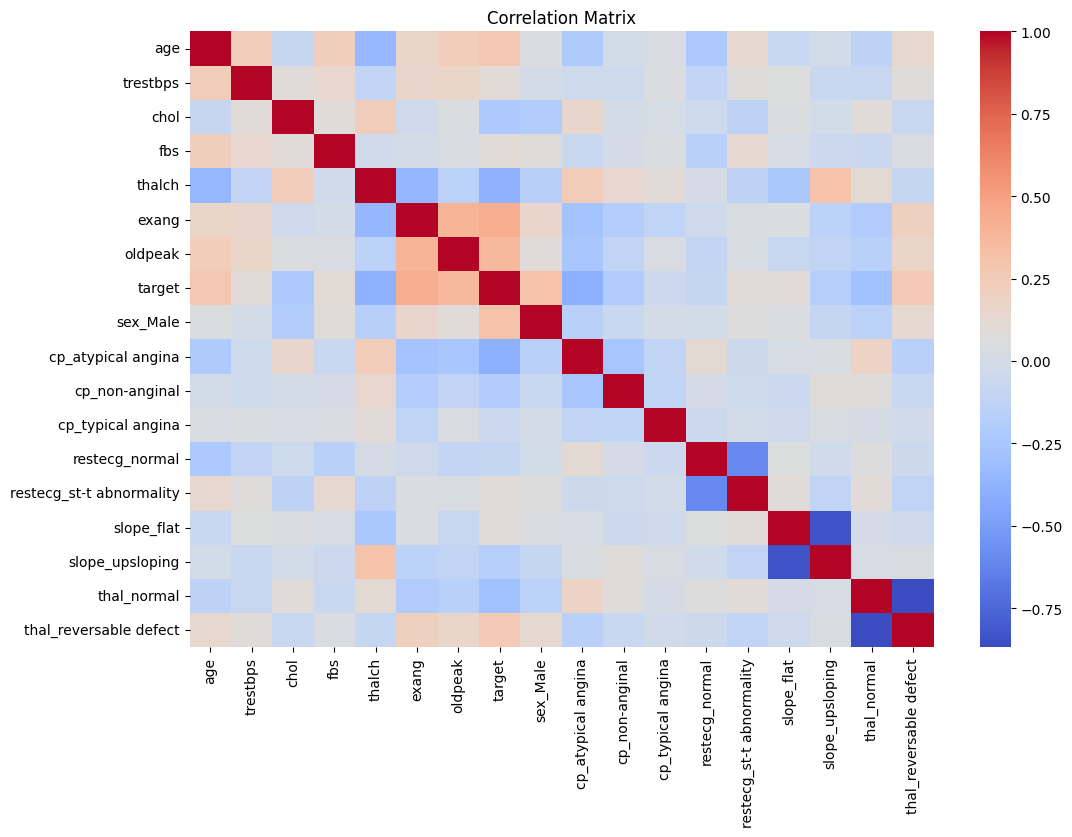

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [12]:
X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [14]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    results[name] = acc

    print(f"--- {name} ---")
    print("Accuracy:", acc)
    print(classification_report(y_test, preds))
    print()

--- Logistic Regression ---
Accuracy: 0.8097826086956522
              precision    recall  f1-score   support

           0       0.76      0.79      0.77        75
           1       0.85      0.83      0.84       109

    accuracy                           0.81       184
   macro avg       0.80      0.81      0.80       184
weighted avg       0.81      0.81      0.81       184


--- KNN ---
Accuracy: 0.8206521739130435
              precision    recall  f1-score   support

           0       0.75      0.84      0.79        75
           1       0.88      0.81      0.84       109

    accuracy                           0.82       184
   macro avg       0.81      0.82      0.82       184
weighted avg       0.83      0.82      0.82       184


--- Random Forest ---
Accuracy: 0.8586956521739131
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        75
           1       0.90      0.86      0.88       109

    accuracy                   

In [15]:
results

{'Logistic Regression': 0.8097826086956522,
 'KNN': 0.8206521739130435,
 'Random Forest': 0.8586956521739131}

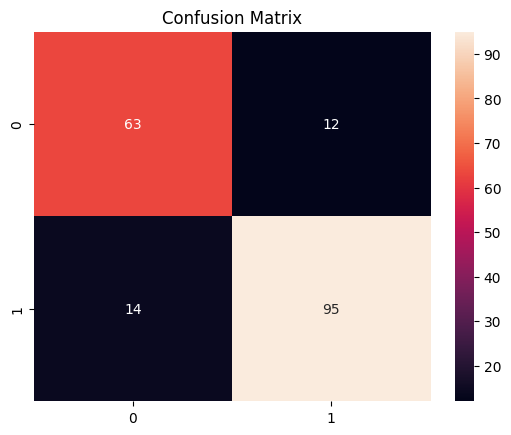

In [16]:
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

preds = best_model.predict(X_test)

sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [18]:
import pickle

# Save model
pickle.dump(best_model, open("model.pkl", "wb"))

# Save column names
pickle.dump(X.columns, open("columns.pkl", "wb"))

## Conclusion

This project successfully built a machine learning model to predict heart disease.

Random Forest achieved the best performance among the tested models.

The model can effectively classify patients based on medical features.

Future improvements:
- Hyperparameter tuning
- More data
- Feature engineering